# CSCI-250: Project 2

## By Lucy Buhayenko

### I'm importing libraries

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### I read data from Walmart_Sales csv and create a dataframe called df

In [102]:
df = pd.read_csv('Walmart_Sales.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


### I check how many rows and columns are in the dateset


In [103]:
df.shape

(6435, 8)

### I check how many missing values there are in each column


### There are 0 missing values in each column so there is no need to drop/replace any values

In [104]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

### Here I check the data types of each column to know if I'll be able to use those columns to create plots, linear regression, quadratic regression, etc.


In [105]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

## Plotting Histograms
##### - Stores are numbered from 1 to 45; There are sales in every store
##### - There are more low to mid range sales(< $1.5 million) then there are those that are >$1.5 million
##### - 0 is no holiday, 1 is holiday. There are much more sales on non-holiday days then on holiday days(since Walmart can just be closed during some holidays)
##### - Sales are much higher when the temperature is around 70 degress Fahrenheit then when the temperature is 100 degrees Fahrenheit, since when it's too hot people don't want to come
##### - Sales are the best when the fuel price is around $3.6
##### - When CPI is low then there are the most sales
##### - When unemployement is too high (13%), then Sales are the lowest

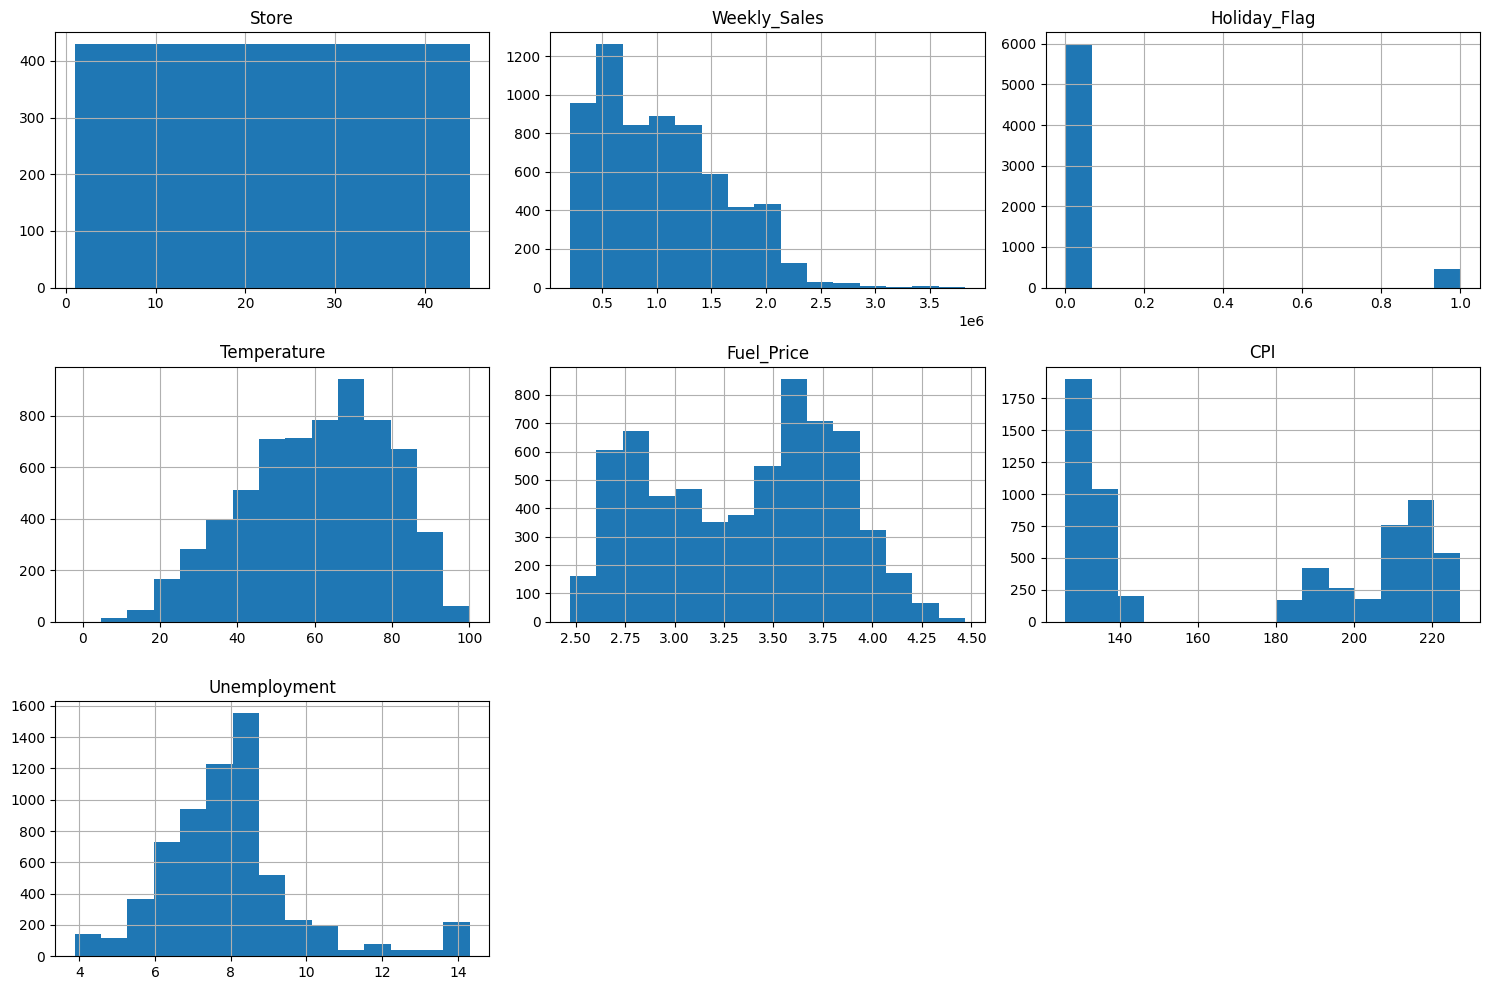

In [106]:
df.hist(figsize=(15, 10), bins=15)
plt.tight_layout()
plt.show()

### I'm splitting the data into features(X) and labels(y)


In [107]:
y = df['Weekly_Sales']

X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

## I'm plotting scatter plots to visualize the relationship between each feature in the dataset X and the target variable (Weekly Sales).
##### - Sales vary widely across stores
##### - Most points are 0 which are not holiday days. There are points called 1 (holidays) it shows that there are lower peaks in sales, meaning that non - holidays are better with sales. Possibly because they are closed on certain holidays
##### - Temperature ranges from 0 to 100, there is no strong correlation
##### - Sales happen across the fuel range of 2.5 to 4.5 dollars
##### - Sales happen across the CPI range (130 to 230)
##### - Sales happen across different unemployment rates (4 - 15)

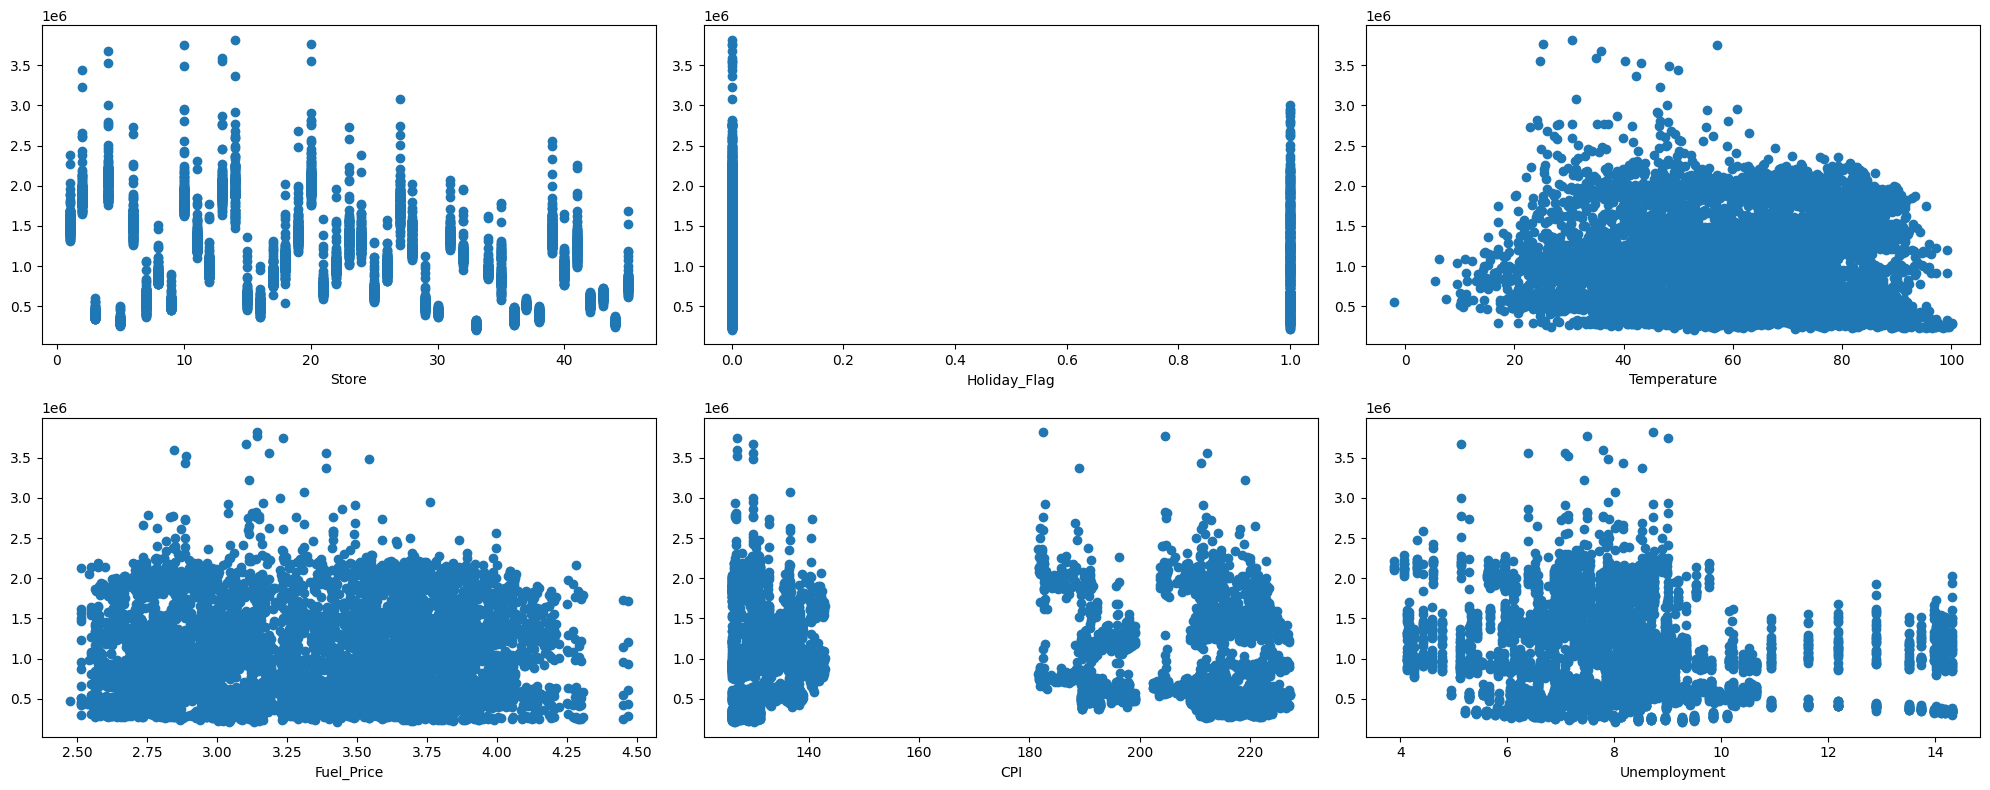

In [108]:
um_cols = len(X.columns)
ncols = 3
nrows = int(np.ceil(um_cols / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], df['Weekly_Sales'])
    axes[i].set_xlabel(col)
# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### I'm plotting the correlation heatmap to see if there are any highly correlated features.

### There is no need for me to remove any features since there is no high correlation. Therefore, the data is clean.

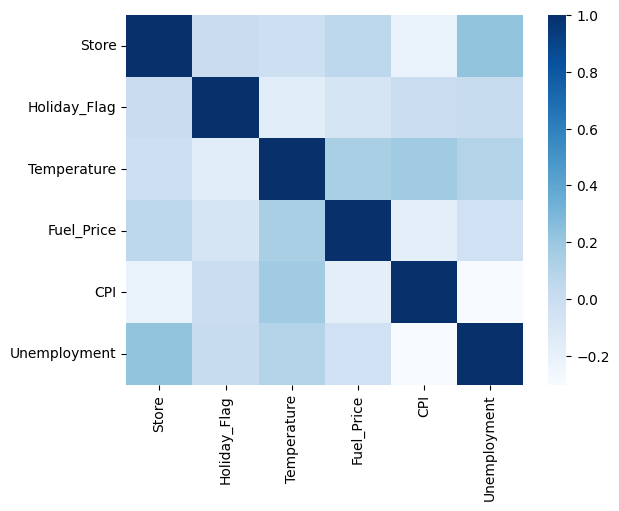

In [109]:
sns.heatmap(X.corr(), annot=False, fmt=".2f", cmap="Blues")
plt.show()

### Histogram of the labels shows distribution of Walmart Weekly Sales. It demostrtrates that majority of sales are low to mid range (< 1.5 million). When sales are >$1.5 million then it's less common.

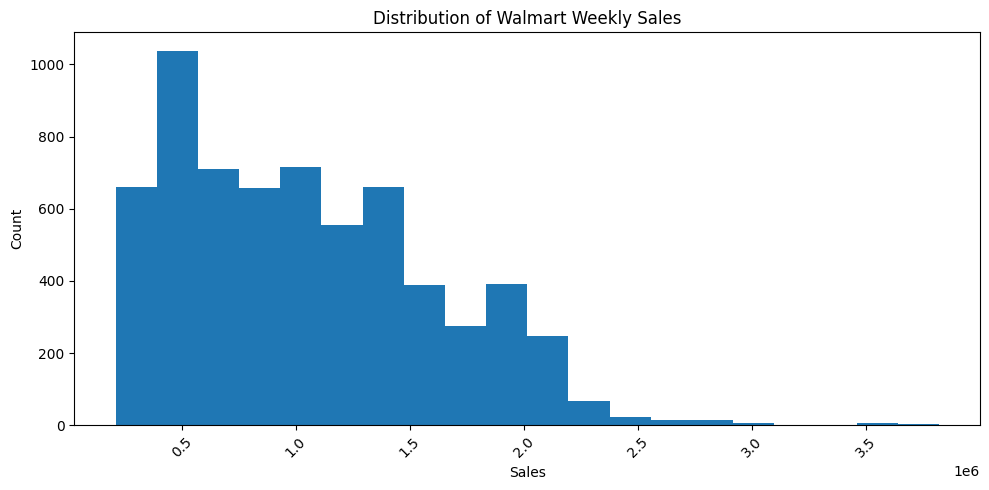

In [110]:
plt.figure(figsize=(10, 5))
plt.hist(df['Weekly_Sales'], bins=20)
plt.ylabel('Count')
plt.xlabel('Sales')
plt.title('Distribution of Walmart Weekly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### I created a categorized scatter plot to visualize the relationship between Store and Fuel Price, with the data points color-coded based on the level of Weekly Sales. Red color is defined as Low Sales(< $1,000,000), Blue color is Mid Sales(between $1,000,000 and $2,000,000) and Green color is High Sales(> $2,000,000).

### The graph shows that the fuel price ranges from $2.50 to $4.50. Majority of points are red and blue, meaning that majority of stores fall into the low to mid sales range across all fuel prices. Based on this graph, we can conclude that fuel price doesn't strongly determine sales levels.

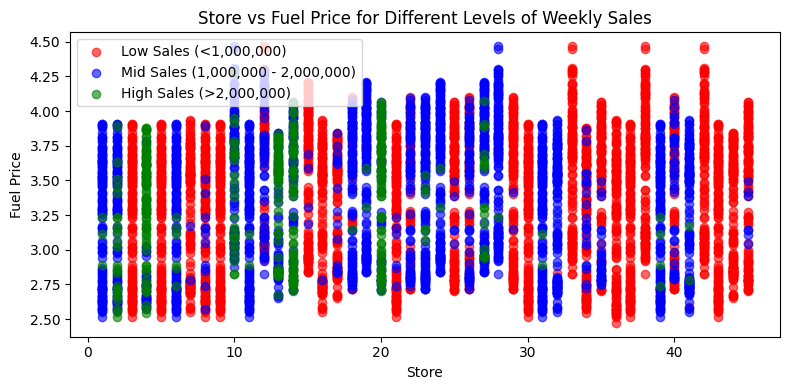

In [111]:
y = df['Weekly_Sales'].values  # y is now Weekly_Sales

# Define sales bins (Low, Mid, High Sales)
low_sales = y < 1000000
mid_sales = (y >= 1000000) & (y < 2000000)
high_sales = y >= 2000000

# Create scatter plots for each sales category
plt.figure(figsize=(8, 4))

# Plot Low Sales
plt.scatter(df['Store'][low_sales], df['Fuel_Price'][low_sales], c='r', label='Low Sales (<1,000,000)', alpha=0.6)

# Plot Mid Sales
plt.scatter(df['Store'][mid_sales], df['Fuel_Price'][mid_sales], c='b', label='Mid Sales (1,000,000 - 2,000,000)', alpha=0.6)

# Plot High Sales
plt.scatter(df['Store'][high_sales], df['Fuel_Price'][high_sales], c='g', label='High Sales (>2,000,000)', alpha=0.6)

# Axis labels and title
plt.xlabel('Store')
plt.ylabel('Fuel Price')
plt.title('Store vs Fuel Price for Different Levels of Weekly Sales')

# Add a legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

### Installing scikit-learn

In [112]:
pip install scikit-learn



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importing tools from scikit-learn: linear_model, metrics, StandartScaler

In [113]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


### Dropping columns: Date, Holiday_Flag and Store, since they are not useful for linear/quadratic regressions because they are categorical(Holiday flag), string value(Date) or just a number that we keep to track order(Store).


In [114]:
df = df.drop(['Date', 'Holiday_Flag', 'Store'], axis=1)

### Here I'm redefining X and y after I dropped 3 columns. Also, I'm converting the data type of X and y from DataFrames to arrays to successfully make linear and quadratic regressions after this.


In [115]:
y = df['Weekly_Sales']

X = df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]


X = X.values
y = y.values

# Splitting Data

### Splitting the data into 80% training set, 10% testing set and 10% validation set. Also, printing the sets' shapes to check whether the data split was correct. The printed shape values prove that everything was splitted correctly, since the training set shape is (5148, 4) (5148,), the validation set shape is (643, 4) (643,) and the testing set shape is (644, 4) (644,)

In [116]:
from sklearn.model_selection import train_test_split

#splitting data into training and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2) # training set = 80%
#making the validation set 
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5) # validation set = 10%; testing set = 10%

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (5148, 4) (5148,)
Validation set shape: (643, 4) (643,)
Test set shape: (644, 4) (644,)


# Scaler

### I standardize the training, validation, and testing datasets for both the feature data (X) and the target data (y). I rescale data to a fixed range (between 0 and 1). I need a scaler because it standardizes the input data, which prevents features with larger numerical values from disproportionately influencing the model's coefficients and ensures faster, more stable training.

In [117]:
#Scaler
scalerX = StandardScaler()
scalery = StandardScaler()

X_train_scaled = scalerX.fit_transform(X_train)
X_val_scaled = scalerX.transform(X_val)
X_test_scaled = scalerX.transform(X_test)

y_train_scaled = scalery.fit_transform(y_train[:,np.newaxis])
y_val_scaled = scalery.fit_transform(y_val[:,np.newaxis])
y_test_scaled = scalery.fit_transform(y_test[:,np.newaxis])

# Linear Regression

### I create and train a linear regression model, then use it to predict values on three sets. I calculate the R2 score for each set, which measures how well the model's predictions match the actual values. The R2 scores in my case are: -3.465177320077397, -3.24552080460312, -3.4671394407460534. This means that linear regression model performs worse than simply predicting the average value of the target variable. The model is a bad fit for the data and has bad predictive accuracy. Also, this might mean that the data is scattered on the whole plot.

In [118]:
regr = linear_model.LinearRegression()

#fitting the model
regr.fit(X_train_scaled, y_train_scaled)

#predictions on the testing set
y_pred_test = regr.predict(X_test_scaled)
#predictions on the training set
y_pred_train = regr.predict(X_train_scaled)
#predictions on the validation set
y_pred_val = regr.predict(X_val_scaled)

#finding coefficients
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
r2_val = r2_score(y_val, y_pred_val)

print(r2_train, r2_test, r2_val)

-3.4350392744962113 -3.529283160454516 -3.4147748733146326


# Quadratic Regression

### I am fitting a quadratic regression model by transforming the input data with PolynomialFeatures before training a standard LinearRegression model. This allows the linear model to capture a curved, non-linear relationship between the features and the target variable by squaring the features in the dataset. The R2 scores are 0.04, 0.05, 0.04. Based on the R2 scores, the quadratic model is the better one. A positive R2 (like 0.5) means the model explains a portion of the variance in the data, while a negative R2 (like -3.4) indicates that the model is a very poor fit and performs worse than simply predicting the mean.

In [119]:
from sklearn.preprocessing import PolynomialFeatures
poly2 = PolynomialFeatures(degree = 2)

X_train_poly2 = poly2.fit_transform(X_train)

lr = linear_model.LinearRegression()
lr.fit(X_train_poly2, y_train)

X_train_transformed = poly2.transform(X_train)
y_pred_train = lr.predict(X_train_transformed)

X_test_transformed = poly2.transform(X_test)
y_pred_test = lr.predict(X_test_transformed)

X_val_transformed = poly2.transform(X_val)
y_pred_val = lr.predict(X_val_transformed)

#R-squared score for the training set, testing set and validation set 
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
r2_val = r2_score(y_val, y_pred_val)

print(f"R2 for the training set: {r2_train:.2f}")
print(f"R2 for the testing set: {r2_test:.2f}")
print(f"R2 for the validation set: {r2_val:.2f}")

R2 for the training set: 0.04
R2 for the testing set: 0.06
R2 for the validation set: 0.05


# Adding a new Row of data and predicting Weekly Sales

### Firstly, I find the medians for 4 features that I have. I store them in xxxx_medians as a list in order to perform scaling. I scale the 4 features and use linear regression to make a prediction of what the weekly sales label could be. After I make a prediction, I unscale the value so that it's not between 0 and 1 anymore but instead could be a value that could be interpreted. I print that the predicted value for the new row is $1,003,806.54270986 of weekly sales, which sounds about right. After that, I unscale the 4 features' medians to see each value. The median for temperature is: 62 Fahrenheit, median for fuel price is $4.92, median for CPI is 7358.21, median for unemployment is 22.77 percent

In [120]:
scalerX.fit(df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
scalery.fit(df[['Weekly_Sales']])

#adding a new row of data

#finding medians 
unscaled_temp_median = 62
fuel_median = df['Fuel_Price'].median()
cpi_median = df['CPI'].median()
ue_median = df['Unemployment'].median()

#creating a list with medians
xxxx_medians = [[unscaled_temp_median, fuel_median, cpi_median, ue_median]]

#making the medians scaled
scaled_medians = scalerX.transform(xxxx_medians)

#making a prediction using the scaled median values
predicted_new_row = regr.predict(scaled_medians)

#inverse transform the prediction to get the value in the original scale
unscaled_medians = scalery.inverse_transform(predicted_new_row)

#printiing the prediction
print(f"The predicted value for the new row is: {unscaled_medians}")

#unscaling the median values by passing the xxxx_medians list to inverse_transform
unscaled_medians = scalerX.inverse_transform(xxxx_medians)
#printing the unscaled medians of each feature
print(f"The unscaled median of Temperature feature is: {unscaled_temp_median} Fahrenheit")
print(f"The unscaled median of Fuel Price feature is: ${unscaled_medians[0][1]:.2f} per gallon")
print(f"The unscaled median of CPI feature is: {unscaled_medians[0][2]:.2f}")
print(f"The unscaled median of Unemployment feature is: {unscaled_medians[0][3]:.2f} percent")



The predicted value for the new row is: [[1033439.6212616]]
The unscaled median of Temperature feature is: 62 Fahrenheit
The unscaled median of Fuel Price feature is: $4.94 per gallon
The unscaled median of CPI feature is: 7358.21
The unscaled median of Unemployment feature is: 22.77 percent


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Plotting ${y}$ and $\tilde{y}$ 

### I am plotting the actual(${y}$) vs predicted ($\tilde{y}$) values in the Training Set and Testing Set. In training set the blue points are clustered near the bottom left and predicitons mostly underestimate higher actual values. This means that the model fits the training data somewhat but it has trouble to capture the higher sales value. In testing set the green points, similarly to the training set, are below the line. This means that the model underpredicts actual values, especially for higher values. Both models show that model can predict lower sales but has problems with predicting higher sales accurately. The models might be underfitting.

<>:9: SyntaxWarning: invalid escape sequence '\~'
<>:16: SyntaxWarning: invalid escape sequence '\~'
<>:9: SyntaxWarning: invalid escape sequence '\~'
<>:16: SyntaxWarning: invalid escape sequence '\~'
/var/folders/3g/czpb9hc56kl8ssmt9pydrw040000gn/T/ipykernel_9911/2393548043.py:9: SyntaxWarning: invalid escape sequence '\~'
  ax1.set_ylabel('Predicted Values ($\~{y}$)')
/var/folders/3g/czpb9hc56kl8ssmt9pydrw040000gn/T/ipykernel_9911/2393548043.py:16: SyntaxWarning: invalid escape sequence '\~'
  ax2.set_ylabel('Predicted Values ($\~{y}$)')


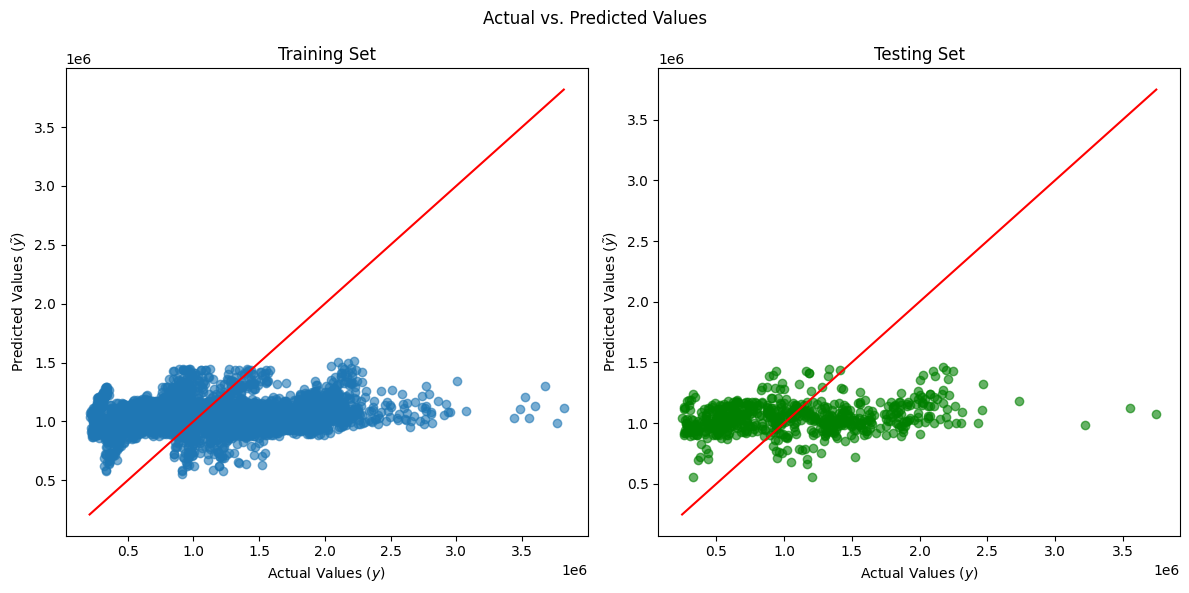

In [121]:
# Setting up the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Actual vs. Predicted Values')

# plot the training set
ax1.scatter(y_train, y_pred_train, alpha=0.6)
ax1.set_title('Training Set')
ax1.set_xlabel('Actual Values ($y$)')
ax1.set_ylabel('Predicted Values ($\~{y}$)')
ax1.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r')

# Plot for the testing set
ax2.scatter(y_test, y_pred_test, alpha=0.6, color='green')
ax2.set_title('Testing Set')
ax2.set_xlabel('Actual Values ($y$)')
ax2.set_ylabel('Predicted Values ($\~{y}$)')
ax2.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r') 


plt.tight_layout()
plt.show()

